In [64]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


In [65]:
MAIN_PATH = "../../data/raw/callisia/"
LEAF_PATH = "Leaf"
OUTPUT_DIR = "./ppg_acc_plots/"

patients = ["P01", "P02", "P03", "P04", "P05"]

# Create output directory
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


In [66]:
def load_patient(patient):
    """Load PPG and ACC data for a patient."""
    path = os.path.join(MAIN_PATH, patient, LEAF_PATH)
    for file in os.listdir(path):
        if file.endswith(".csv") and "ppg" in file:
            ppg_df = pd.read_csv(os.path.join(path, file))
            print(f"Patient: {patient}, File: {file}, Shape: {ppg_df.shape}")
            print(f"Columns: {list(ppg_df.columns)}\n")
            return ppg_df
    return None


In [67]:
def extract_signals(df):
    """Extract PPG GREEN signal and ACC signals from dataframe with datetime info."""
    try:
        # Detect time column
        time_col = None
        datetime_col = None
        for col in ['timestamp_ms', 'timestamp', 'time']:
            if col in df.columns:
                time_col = col
                break

        # Detect datetime column
        for col in ['datetime', 'date_time', 'date']:
            if col in df.columns:
                datetime_col = col
                break

        if time_col is None:
            time = np.arange(len(df))
            start_time_str = "N/A"
            end_time_str = "N/A"
        else:
            time = df[time_col].values

            # Convert to seconds if in milliseconds
            if time_col == 'timestamp_ms' and time.max() > 1e10:
                time = time / 1000.0

            # Extract start and end times
            if datetime_col is not None:
                start_time_str = str(df[datetime_col].iloc[0])
                end_time_str = str(df[datetime_col].iloc[-1])
            else:
                start_time_str = f"{time[0]:.2f}s"
                end_time_str = f"{time[-1]:.2f}s"

        # Detect PPG GREEN channel
        ppg_green = None
        for col in df.columns:
            if 'green' in col.lower():
                ppg_green = df[col].values
                break

        if ppg_green is None:
            logger.warning(f"PPG GREEN channel not found in columns: {df.columns.tolist()}")
            return None, None, None, None, None

        # Detect ACC channels
        acc_x = None
        acc_y = None
        acc_z = None

        for col in df.columns:
            col_lower = col.lower()
            if 'acc' in col_lower and 'x' in col_lower:
                acc_x = df[col].values
            elif 'acc' in col_lower and 'y' in col_lower:
                acc_y = df[col].values
            elif 'acc' in col_lower and 'z' in col_lower:
                acc_z = df[col].values

        if acc_x is None or acc_y is None or acc_z is None:
            logger.warning(f"ACC channels incomplete. X={acc_x is not None}, Y={acc_y is not None}, Z={acc_z is not None}")
            return None, None, None, None, None

        return time, ppg_green, np.column_stack((acc_x, acc_y, acc_z)), start_time_str, end_time_str

    except Exception as e:
        logger.error(f"Error extracting signals: {e}")
        return None, None, None, None, None


In [68]:
def plot_patient_signals(patient):
    """Create and save visualization for a patient's PPG and ACC signals."""
    logger.info(f"Processing patient {patient}...")

    # Load data
    df = load_patient(patient)
    if df is None or df.empty:
        logger.error(f"Failed to load data for {patient}")
        return False

    # Extract signals
    time, ppg_green, acc_xyz, start_time, end_time = extract_signals(df)
    if time is None or ppg_green is None or acc_xyz is None:
        logger.error(f"Failed to extract signals for {patient}")
        return False

    # Create figure with subplots
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))

    # Format title with datetime info
    time_range_str = f"Start: {start_time}\nEnd: {end_time}"
    fig.suptitle(f"Patient {patient} - PPG (GREEN) and ACC Signals\n{time_range_str}",
                 fontsize=14, fontweight='bold')

    # Plot PPG GREEN
    axes[0].plot(time, ppg_green, color='green', linewidth=0.8, alpha=0.8)
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('PPG GREEN (a.u.)')
    axes[0].set_title('Photoplethysmogram - GREEN Channel')
    axes[0].grid(True, alpha=0.3)

    # Plot ACC X
    axes[1].plot(time, acc_xyz[:, 0], color='red', linewidth=0.8, alpha=0.8, label='ACC_X')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Acceleration (mg)')
    axes[1].set_title('Accelerometer - X Axis')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Plot ACC Y
    axes[2].plot(time, acc_xyz[:, 1], color='blue', linewidth=0.8, alpha=0.8, label='ACC_Y')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Acceleration (mg)')
    axes[2].set_title('Accelerometer - Y Axis')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    # Plot ACC Z
    axes[3].plot(time, acc_xyz[:, 2], color='purple', linewidth=0.8, alpha=0.8, label='ACC_Z')
    axes[3].set_xlabel('Time (s)')
    axes[3].set_ylabel('Acceleration (mg)')
    axes[3].set_title('Accelerometer - Z Axis')
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    plt.tight_layout()

    # Save figure
    output_file = os.path.join(OUTPUT_DIR, f"{patient}_ppg_acc_signals.png")
    try:
        plt.savefig(output_file, dpi=150, bbox_inches='tight')
        logger.info(f"✓ Saved plot: {output_file}")
    except Exception as e:
        logger.error(f"Failed to save plot for {patient}: {e}")
        return False

    plt.show()
    return True


In [69]:
def plot_combined_acc(patient):
    """Create a combined plot showing all 3 ACC axes together for a patient."""
    logger.info(f"Creating combined ACC plot for patient {patient}...")

    df = load_patient(patient)
    if df is None or df.empty:
        logger.error(f"Failed to load data for {patient}")
        return False

    time, _, acc_xyz, start_time, end_time = extract_signals(df)
    if time is None or acc_xyz is None:
        logger.error(f"Failed to extract ACC signals for {patient}")
        return False

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(time, acc_xyz[:, 0], label='ACC_X (Red)', color='red', linewidth=0.8, alpha=0.8)
    ax.plot(time, acc_xyz[:, 1], label='ACC_Y (Blue)', color='blue', linewidth=0.8, alpha=0.8)
    ax.plot(time, acc_xyz[:, 2], label='ACC_Z (Purple)', color='purple', linewidth=0.8, alpha=0.8)

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Acceleration (mg)', fontsize=12)

    # Add time range info to title
    time_range_str = f"Start: {start_time} | End: {end_time}"
    ax.set_title(f'Patient {patient} - All ACC Axes Combined\n{time_range_str}',
                 fontsize=13, fontweight='bold')

    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    output_file = os.path.join(OUTPUT_DIR, f"{patient}_acc_combined.png")
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    logger.info(f"✓ Saved combined ACC plot: {output_file}")
    plt.show()

    return True


2026-05-15 10:02:25,399 - INFO - Processing patient P01...


GENERATING PPG & ACC PLOTS FOR ALL PATIENTS

Patient: P01, File: ppg_acc_1777458615613.csv, Shape: (388697, 7)
Columns: ['timestamp_ms', 'green', 'red', 'infrared', 'acc_x', 'acc_y', 'acc_z']



2026-05-15 10:02:26,810 - INFO - ✓ Saved plot: ./ppg_acc_plots/P01_ppg_acc_signals.png


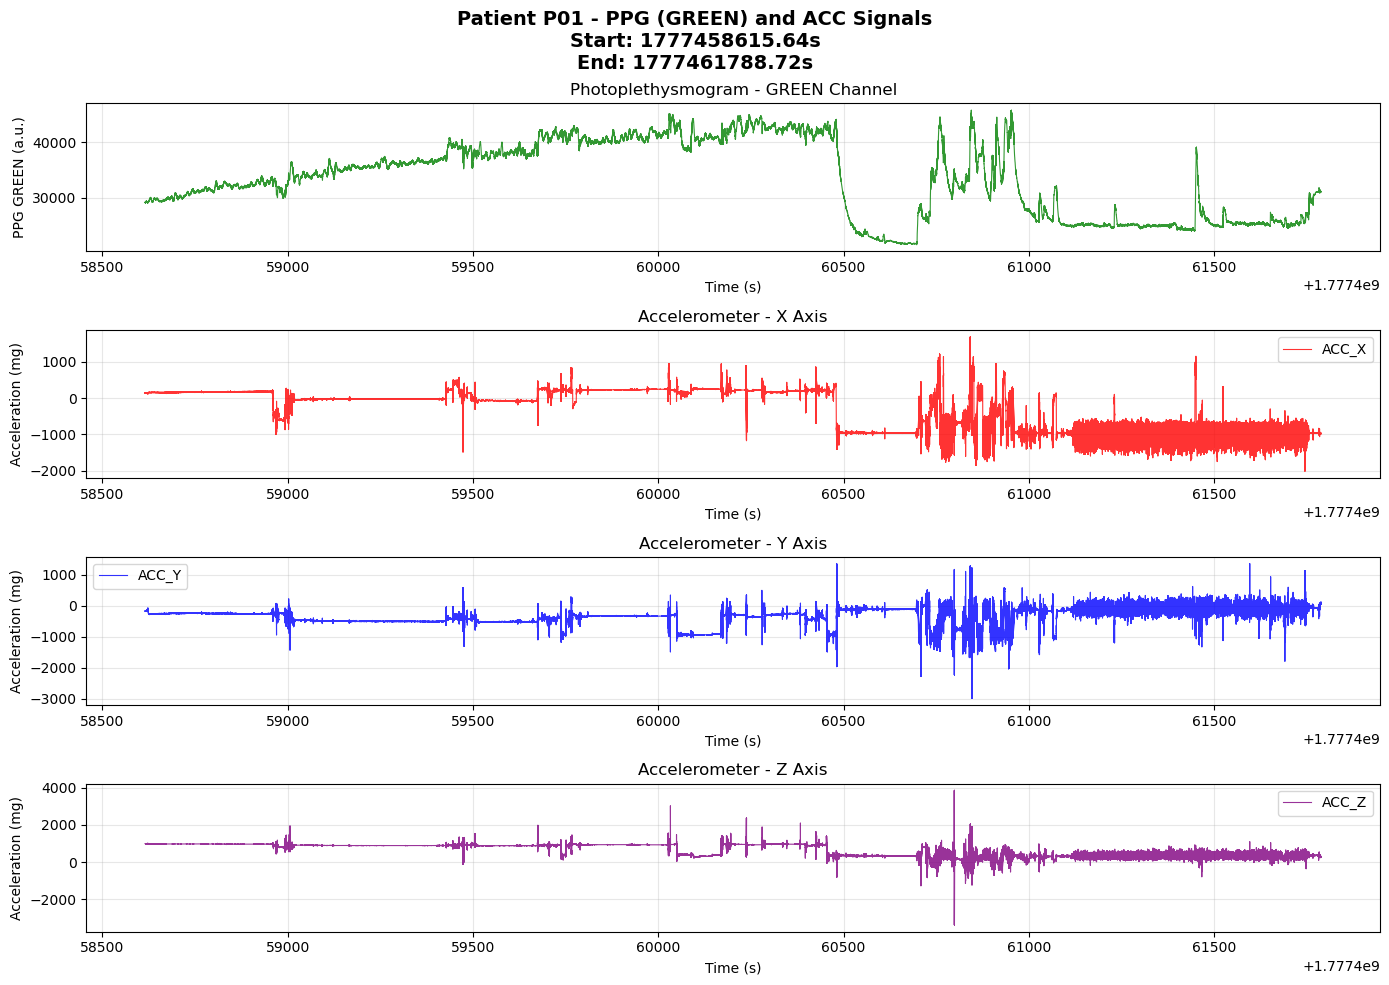

2026-05-15 10:02:27,367 - INFO - Processing patient P02...



Patient: P02, File: ppg_acc_1777473264919.csv, Shape: (290959, 7)
Columns: ['timestamp_ms', 'green', 'red', 'infrared', 'acc_x', 'acc_y', 'acc_z']



2026-05-15 10:02:28,460 - INFO - ✓ Saved plot: ./ppg_acc_plots/P02_ppg_acc_signals.png


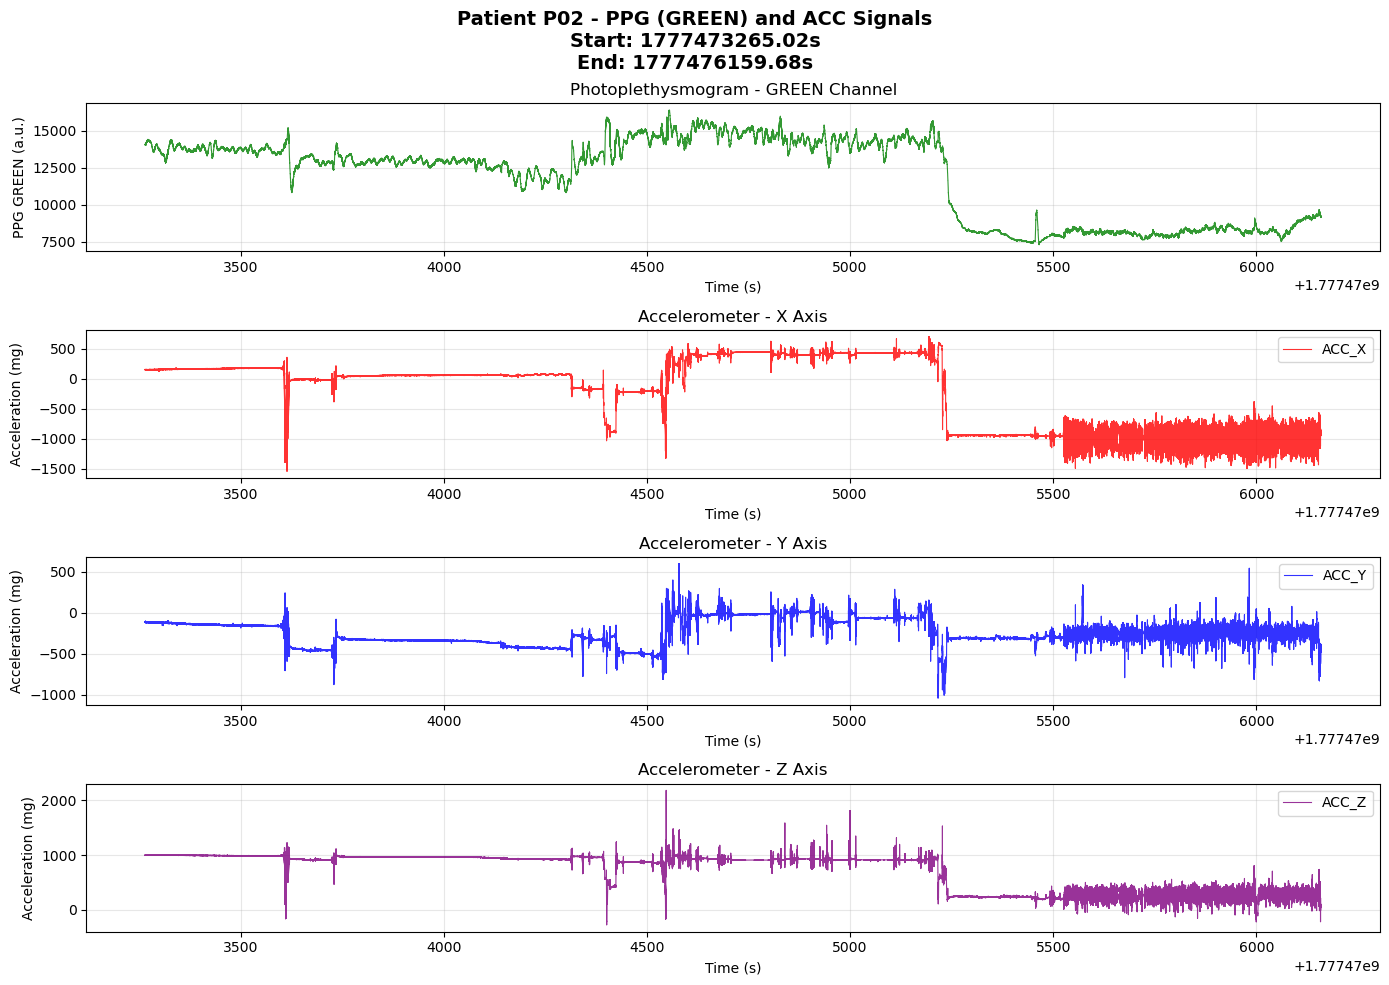

2026-05-15 10:02:28,885 - INFO - Processing patient P03...



Patient: P03, File: ppg_acc_1777478834211.csv, Shape: (280372, 7)
Columns: ['timestamp_ms', 'green', 'red', 'infrared', 'acc_x', 'acc_y', 'acc_z']



2026-05-15 10:02:30,036 - INFO - ✓ Saved plot: ./ppg_acc_plots/P03_ppg_acc_signals.png


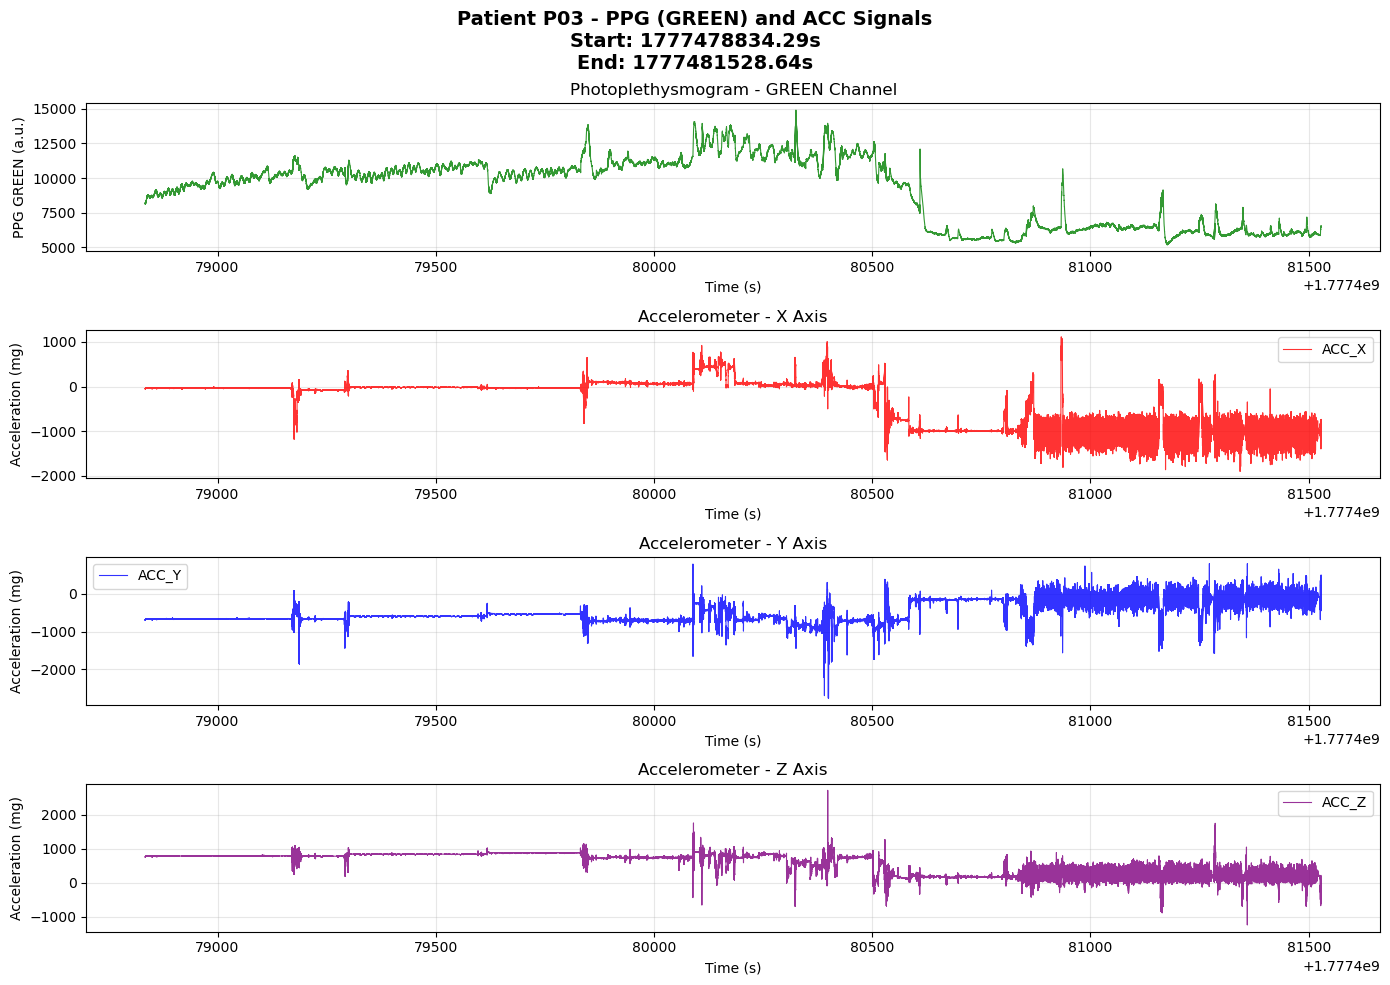

2026-05-15 10:02:30,494 - INFO - Processing patient P04...



Patient: P04, File: ppg_acc_1777828389151.csv, Shape: (283436, 7)
Columns: ['timestamp_ms', 'green', 'red', 'infrared', 'acc_x', 'acc_y', 'acc_z']



2026-05-15 10:02:31,586 - INFO - ✓ Saved plot: ./ppg_acc_plots/P04_ppg_acc_signals.png


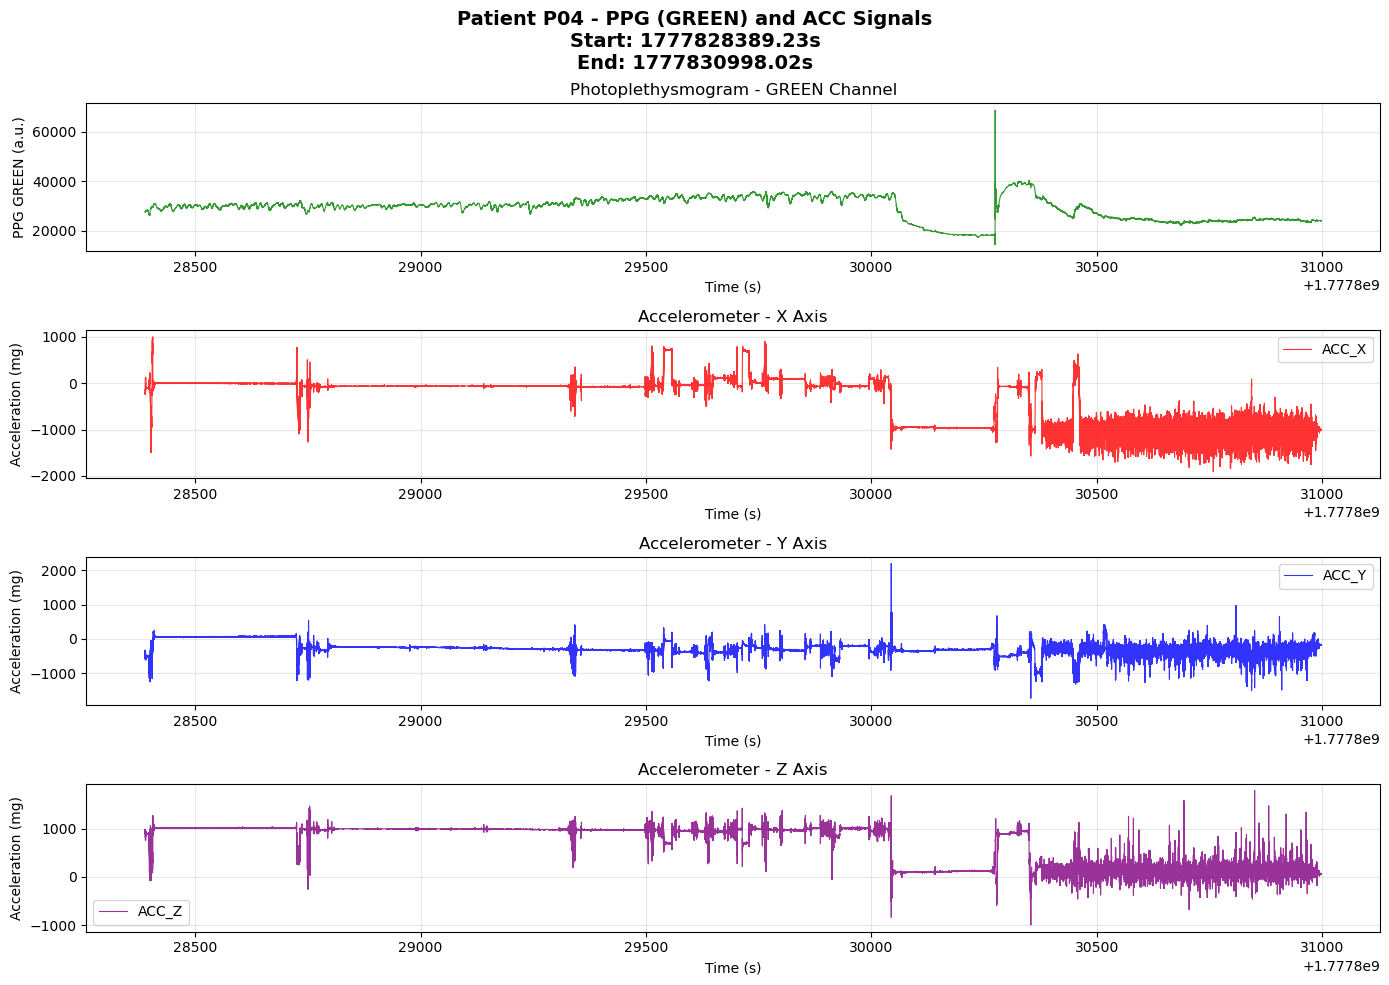

2026-05-15 10:02:32,041 - INFO - Processing patient P05...



Patient: P05, File: ppg_acc_1777837508143.csv, Shape: (338235, 7)
Columns: ['timestamp_ms', 'green', 'red', 'infrared', 'acc_x', 'acc_y', 'acc_z']



2026-05-15 10:02:33,541 - INFO - ✓ Saved plot: ./ppg_acc_plots/P05_ppg_acc_signals.png


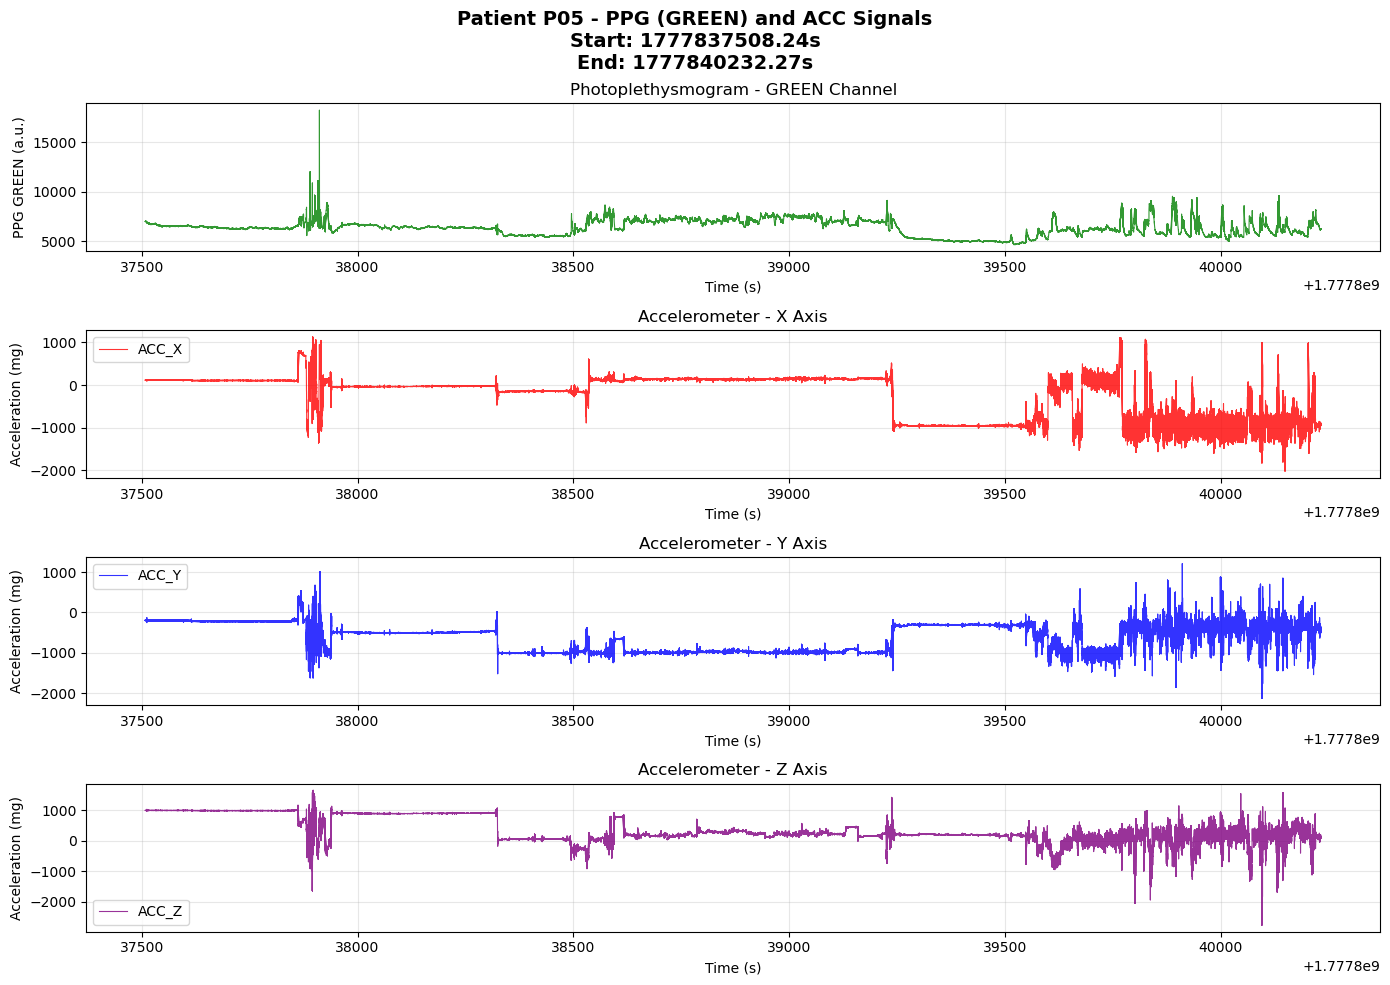


✓ Successfully processed 5/5 patients
✓ Plots saved to: C:\Users\seghi\Desktop\University\Master University\Passau University\Studies\Sommersemester 2026\Callisia\notebooks\callisia\ppg_acc_plots



In [70]:
# Generate individual plots for each patient
print("="*60)
print("GENERATING PPG & ACC PLOTS FOR ALL PATIENTS")
print("="*60 + "\n")

success_count = 0
for patient in patients:
    if plot_patient_signals(patient):
        success_count += 1
    print()

print("="*60)
print(f"✓ Successfully processed {success_count}/{len(patients)} patients")
print(f"✓ Plots saved to: {os.path.abspath(OUTPUT_DIR)}")
print("="*60 + "\n")


2026-05-15 10:02:34,191 - INFO - Creating combined ACC plot for patient P01...


GENERATING COMBINED ACC PLOTS FOR ALL PATIENTS

Patient: P01, File: ppg_acc_1777458615613.csv, Shape: (388697, 7)
Columns: ['timestamp_ms', 'green', 'red', 'infrared', 'acc_x', 'acc_y', 'acc_z']



2026-05-15 10:02:35,443 - INFO - ✓ Saved combined ACC plot: ./ppg_acc_plots/P01_acc_combined.png


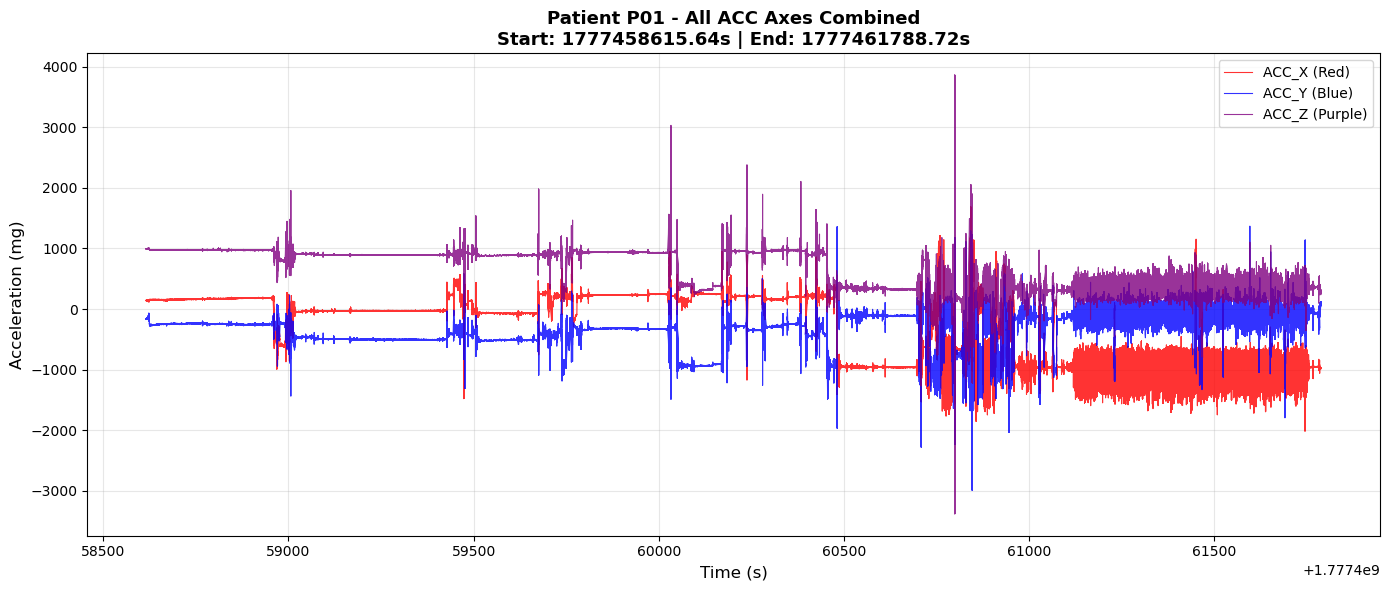

2026-05-15 10:02:35,958 - INFO - Creating combined ACC plot for patient P02...



Patient: P02, File: ppg_acc_1777473264919.csv, Shape: (290959, 7)
Columns: ['timestamp_ms', 'green', 'red', 'infrared', 'acc_x', 'acc_y', 'acc_z']



2026-05-15 10:02:36,980 - INFO - ✓ Saved combined ACC plot: ./ppg_acc_plots/P02_acc_combined.png


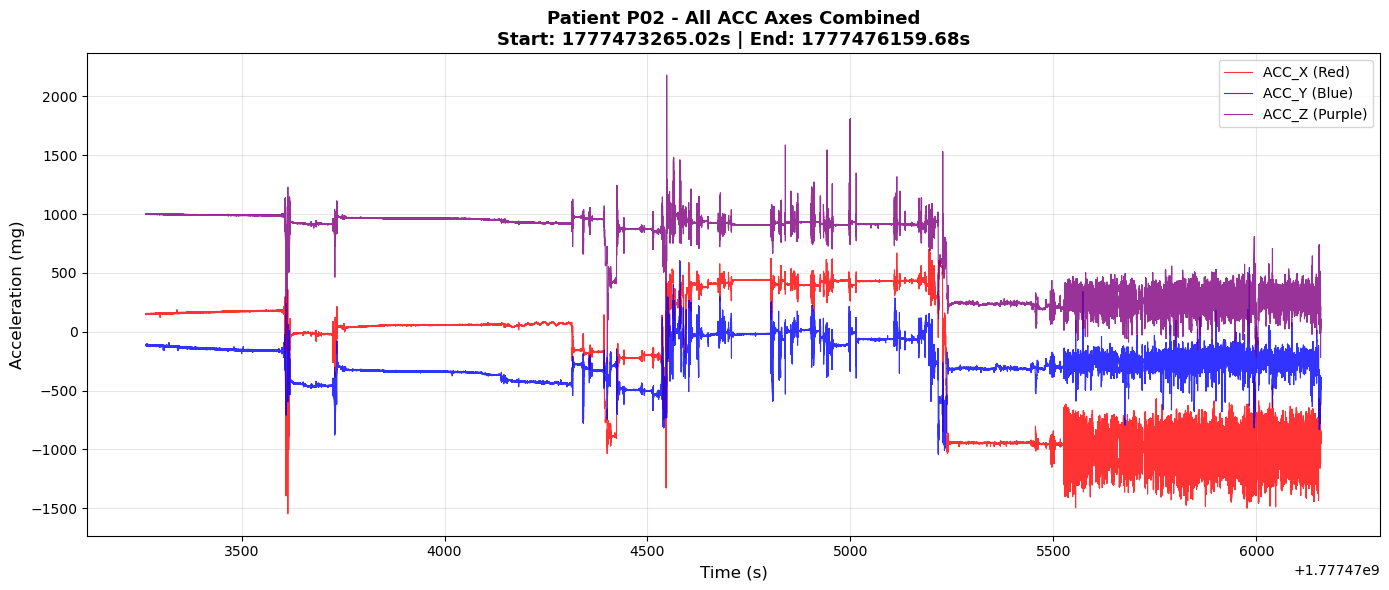

2026-05-15 10:02:37,361 - INFO - Creating combined ACC plot for patient P03...



Patient: P03, File: ppg_acc_1777478834211.csv, Shape: (280372, 7)
Columns: ['timestamp_ms', 'green', 'red', 'infrared', 'acc_x', 'acc_y', 'acc_z']



2026-05-15 10:02:38,361 - INFO - ✓ Saved combined ACC plot: ./ppg_acc_plots/P03_acc_combined.png


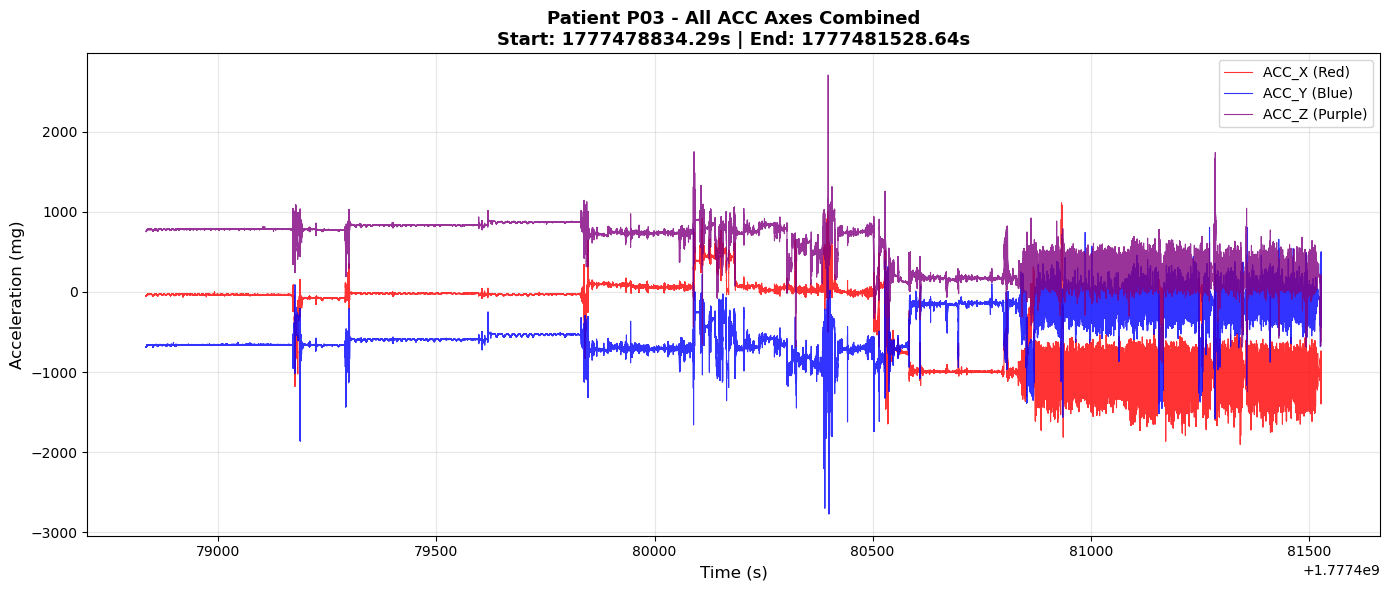

2026-05-15 10:02:38,727 - INFO - Creating combined ACC plot for patient P04...



Patient: P04, File: ppg_acc_1777828389151.csv, Shape: (283436, 7)
Columns: ['timestamp_ms', 'green', 'red', 'infrared', 'acc_x', 'acc_y', 'acc_z']



2026-05-15 10:02:39,915 - INFO - ✓ Saved combined ACC plot: ./ppg_acc_plots/P04_acc_combined.png


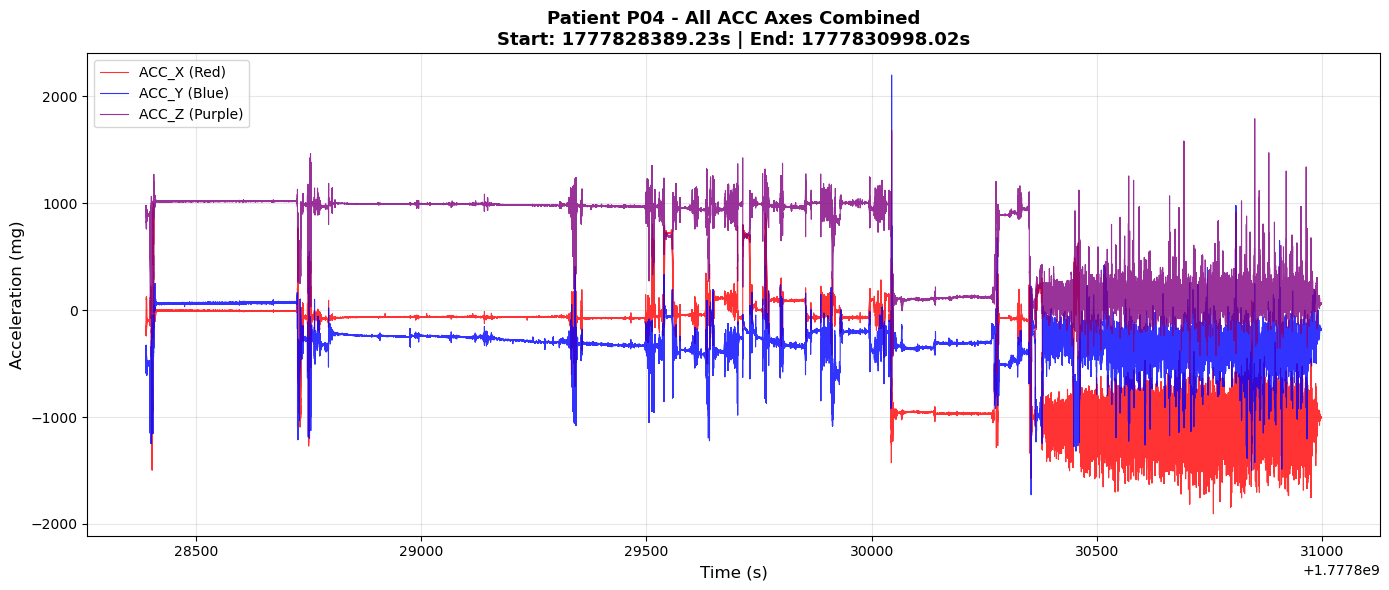

2026-05-15 10:02:40,413 - INFO - Creating combined ACC plot for patient P05...



Patient: P05, File: ppg_acc_1777837508143.csv, Shape: (338235, 7)
Columns: ['timestamp_ms', 'green', 'red', 'infrared', 'acc_x', 'acc_y', 'acc_z']



2026-05-15 10:02:41,770 - INFO - ✓ Saved combined ACC plot: ./ppg_acc_plots/P05_acc_combined.png


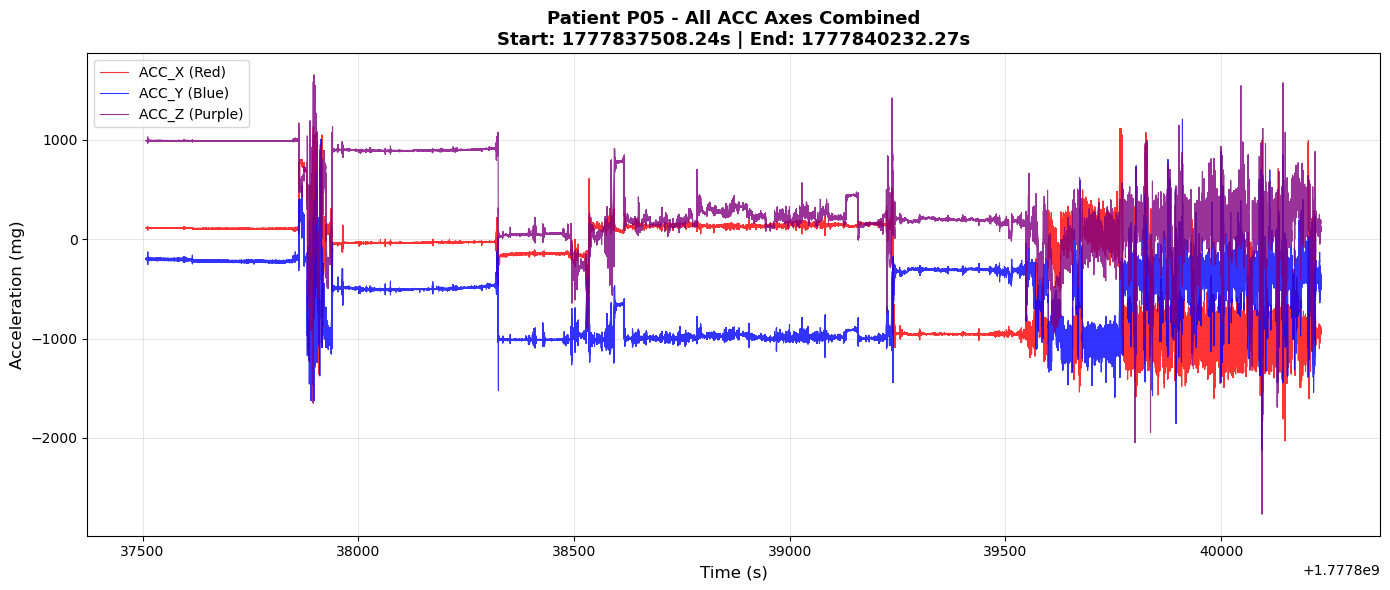


✓ All plots generated successfully!


In [71]:
# Generate combined ACC plots for each patient
print("="*60)
print("GENERATING COMBINED ACC PLOTS FOR ALL PATIENTS")
print("="*60 + "\n")

for patient in patients:
    plot_combined_acc(patient)
    print()

print("="*60)
print("✓ All plots generated successfully!")
print("="*60)
